# Histopathologic Cancer Detection EDA


In [ ]:
# =========================
# 1. Imports & Config
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
from tqdm import tqdm
import torch
import os
from sklearn.decomposition import PCA

# Paths
# Need to change path
TRAIN_DIR = Path(r"C:\Users\Lenovo\Desktop\Histo\data\train")
TEST_DIR  = Path(r"C:\Users\Lenovo\Desktop\Histo\data\test")
LABELS_CSV = Path(r"C:\Users\Lenovo\Desktop\Histo\data\train_labels.csv")

# Config
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

print("Configuration loaded successfully.")

print(TRAIN_DIR)
print(TEST_DIR)
print(LABELS_CSV)

Configuration loaded successfully.
C:\Users\Lenovo\Desktop\PROJECT\data\train
C:\Users\Lenovo\Desktop\PROJECT\data\test
C:\Users\Lenovo\Desktop\PROJECT\data\train_labels.csv


In [2]:
# Load labels
df = pd.read_csv(LABELS_CSV)

print(f"Total number of images: {len(df):,}")
print("\nFirst 5 rows:")
print(df.head())

Total number of images: 220,025

First 5 rows:
                                         id  label
0  f38a6374c348f90b587e046aac6079959adf3835      0
1  c18f2d887b7ae4f6742ee445113fa1aef383ed77      1
2  755db6279dae599ebb4d39a9123cce439965282d      0
3  bc3f0c64fb968ff4a8bd33af6971ecae77c75e08      0
4  068aba587a4950175d04c680d38943fd488d6a9d      0


## Picture samples

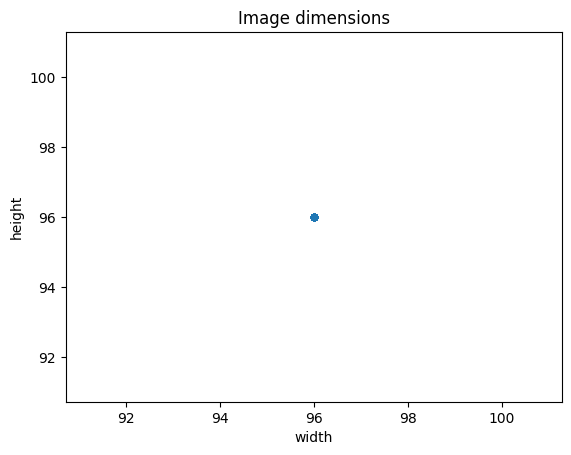

In [3]:
sizes = []

for img_name in os.listdir(TRAIN_DIR)[:100]:
    img = Image.open(os.path.join(TRAIN_DIR, img_name))
    sizes.append(img.size)

sizes_df = pd.DataFrame(sizes, columns=['width','height'])
sizes_df.plot(kind='scatter', x='width', y='height', title='Image dimensions')
plt.show()

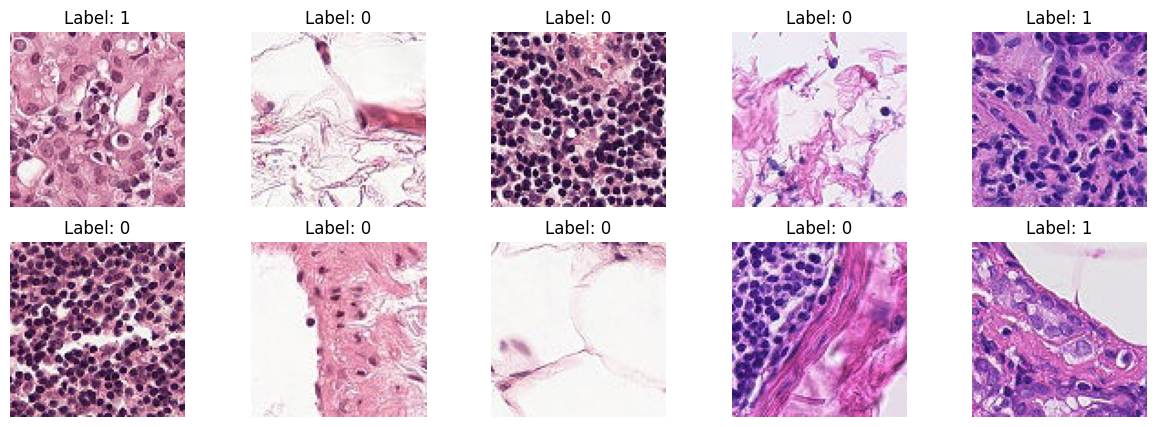

In [4]:
fig, axes = plt.subplots(2,5, figsize=(15,5))
sample_images = os.listdir(TRAIN_DIR)[:10]

for ax, img_name in zip(axes.flatten(), sample_images):
    img = Image.open(os.path.join(TRAIN_DIR, img_name))
    ax.imshow(img)
    ax.set_title(f"Label: {df[df['id']==img_name.split('.')[0]]['label'].values[0]}")
    ax.axis('off')

plt.show()

## Class Distribution


Class distribution:
label
0    130908
1     89117
Name: count, dtype: int64


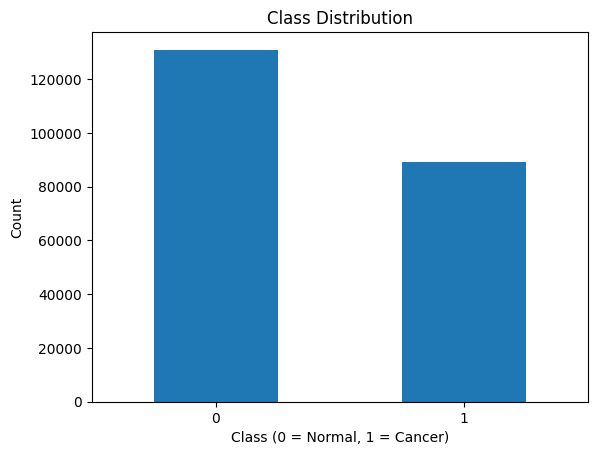


Imbalance ratio (Normal/Cancer): 1.47


In [5]:
print("\nClass distribution:")
print(df["label"].value_counts())

# Plot class distribution
df["label"].value_counts().plot(kind="bar")
plt.title("Class Distribution")
plt.xlabel("Class (0 = Normal, 1 = Cancer)")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

# Check imbalance ratio
counts = df["label"].value_counts()
ratio = counts[0] / counts[1]

print(f"\nImbalance ratio (Normal/Cancer): {ratio:.2f}")

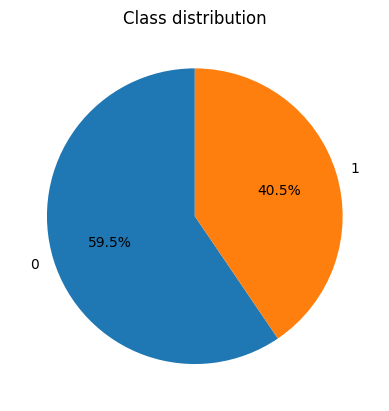

In [6]:
df['label'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90)
plt.title('Class distribution')
plt.ylabel('')
plt.show()

In [7]:
print("Total rows in CSV:", len(df))

# Keep only existing images
existing_ids = set([f.replace('.tif', '') for f in os.listdir(TRAIN_DIR)])

df_filtered = df[df['id'].isin(existing_ids)].reset_index(drop=True)

print("Available images:", len(df_filtered))

# Take sample
sample_size = 2000  
sample_df = df_filtered.sample(n=sample_size, random_state=42).reset_index(drop=True)

# Load images
images = []
labels = []

for i in range(len(sample_df)):
    img_name = sample_df.loc[i, 'id'] + '.tif'
    img_path = os.path.join(TRAIN_DIR, img_name)

    try:
        img = Image.open(img_path).convert("RGB") 
        img = np.array(img)

        images.append(img)
        labels.append(sample_df.loc[i, 'label'])

    except Exception as e:
        print(f"Error loading {img_name}: {e}")

# Convert to numpy
images = np.array(images)
labels = np.array(labels)

print("Images shape:", images.shape)   
print("Labels shape:", labels.shape)   

Total rows in CSV: 220025
Available images: 20247
Images shape: (2000, 96, 96, 3)
Labels shape: (2000,)


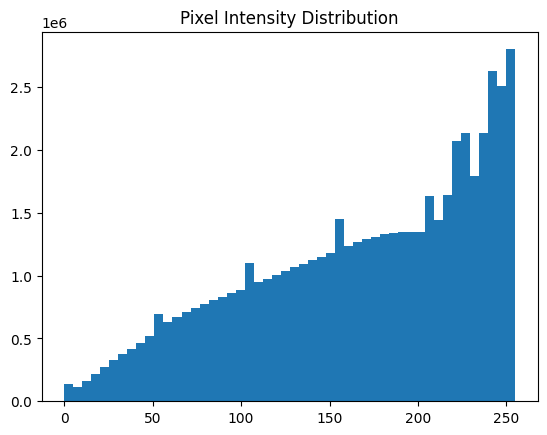

In [8]:
plt.hist(images.flatten(), bins=50)
plt.title("Pixel Intensity Distribution")
plt.show()

The histogram shows a higher concentration of pixels in the 200–255 range, indicating bright histopathological images. This may impact feature extraction, making normalization and augmentation important.

2D shape: (2000, 2)


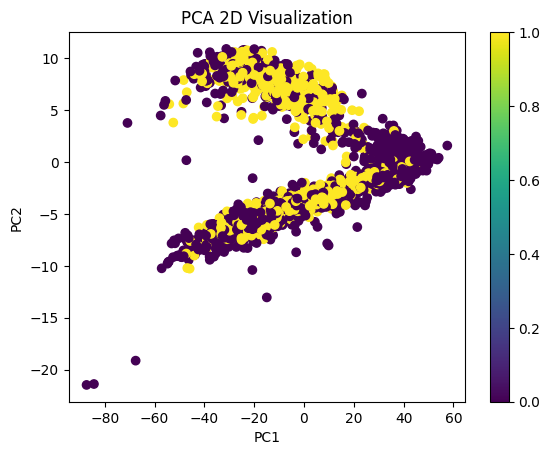

In [ ]:
# Flatten 
N = images.shape[0]
images_flat = images.reshape(N, -1)

# Normalize
images_flat = images_flat / 255.0

# PCA → 2D
pca = PCA(n_components=2)
images_2d = pca.fit_transform(images_flat)

print("2D shape:", images_2d.shape)  

# Scatter plot
plt.figure()
plt.scatter(images_2d[:, 0], images_2d[:, 1], c=labels)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA 2D Visualization")
plt.colorbar()
plt.show()